In [ ]:
# Install required packages in Google Colab.
!pip -q install imbalanced-learn xgboost shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from pathlib import Path
import json
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import imblearn
import xgboost
import shap
import lime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
TEST_SIZE = 0.20
DATA_PATH = Path("/content/drive/MyDrive/JURNAL/second_order_df.csv")
OUTPUT_DIR = Path("/content/drive/MyDrive/JURNAL/round3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "imbalanced_learn": imblearn.__version__,
    "xgboost": xgboost.__version__,
    "shap": shap.__version__,
    "lime": getattr(lime, "__version__", "not exposed"),
}
print(json.dumps(SOFTWARE_VERSIONS, indent=2))
with open(OUTPUT_DIR / "software_versions.json", "w") as f:
    json.dump(SOFTWARE_VERSIONS, f, indent=2)

{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pandas": "2.2.2",
  "numpy": "2.0.2",
  "scikit_learn": "1.6.1",
  "imbalanced_learn": "0.14.2",
  "xgboost": "3.3.0",
  "shap": "0.52.0",
  "lime": "not exposed"
}


In [ ]:
import os

print(os.path.exists("/content/drive"))
print(os.listdir("/content"))

True
['.config', 'drive', 'sample_data']


In [ ]:
# Ambil 100 baris pertama
sample_df = df.head(100)

# Simpan menjadi CSV
sample_df.to_csv("ethereum_transaction_sample.csv", index=False)

In [ ]:
from google.colab import files
files.download("ethereum_transaction_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls "/content/drive/MyDrive/JURNAL"

round3_outputs


In [ ]:
import shutil
import os

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['cv_indana Zulfa.pdf', 'hardwaresoftware3_23.11.5661_IndanaZulfa.pdf', 'hardware software _23.11.5661.pdf', 'tugas5_indanazulfa_23.11.5661.pdf', 'indana zulfa_23.11.5661_hardwaresoftware.pdf', 'hardware software7_23.11.5661_indana zulfa.pdf', 'ST073_IndanaZulfa_23.11.5661.pdf', 'Roadshow Reku dan Tether Jogja Event.pkpass', '23.11 (1).5661_IndanaZulfa.pdf', 'tugas2_23.11.5661_IndanaZulfa.pdf', 'sistembasisdata_indanazulfa_23.11.5661.drawio', '23.11.5661_IndanaZulfa.pdf', '23.11 (2).5661_INDANAZULFA_MATHDISKRIT.pdf', 'bsd2.drawio', '23.11.5661_INDANAZULFA_ORKOM.pdf', '23.11 (1).5661_INDANAZULFA_MATHDISKRIT.pdf', '23.11.5661_INDANAZULFA_MATHDISKRIT.pdf', '23.11.5661_Indanazulfa_ORKOM.pdf', '23.11.5661_INDANAZULFA_ENGLISH.mp4', '23.11.5661_Indanazulfa_orkom.pdf', '23.11.5661_IndanaZulfa_matematikadiskrit.pdf', 'pemogramanlanjut.drawio', 'IndanaZulfa_23.11.5661_mathdiskrit.pdf', '23.11.5661_IndanaZulfa.Mathdiskrit8.pdf', '23.11.5661_INDANAZULFA_MATHDISKRIT10.pdf', '23.11.5661_INDANAZULFA_

In [ ]:
DATA_PATH = Path("/content/drive/MyDrive/Dataset/second_order_df.csv")

In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/drive"))

['.config', 'drive', 'sample_data']
['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
!find /content -name "second_order_df.csv"

/content/drive/MyDrive/JURNAL/second_order_df.csv


In [ ]:
print(DATA_PATH)

/content/drive/MyDrive/Dataset/second_order_df.csv


In [ ]:
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/JURNAL/second_order_df.csv")

In [ ]:
import os

os.listdir("/content/drive/MyDrive/JURNAL")

['second_order_df.csv',
 'isi',
 ' ISI3',
 'Copy of ISI2',
 ' of ISI2',
 'ISI2(revisi)',
 'ISI(REVISITERBARU).ipynb',
 'round3_outputs',
 'round3_outputs.zip',
 'Copy of ISI_PAKKS',
 'ISI_REVISIIIII2']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/JURNAL/second_order_df.csv", nrows=5)
df.head()

,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0x8ce1d46abe9e2be0712ecc078bc8f3234ba4a4568e33...,5659116,1527017753,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.586269,0
1,1,0x8ae1819a3202c31f9305282e36bed4825a949813a775...,5679819,1527335634,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0x6ab5cb8793bef44a90ba8beb6d966850cd5dab29,0.585408,0
2,2,0x1dd9fa9a81528d66791bd3f5e8ea0583aa126e897c6c...,5686368,1527435806,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.947515,0
3,3,0x9e016e0b56518ef7e3b85590469dd44ead20eaebda48...,5696896,1527595105,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0xfb03e59c83b984da0f6a5575b955541af28ccc65,0.947284,0
4,4,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0


In [ ]:
raw_df = pd.read_csv(DATA_PATH, nrows=5)
raw_df.head()

,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0x8ce1d46abe9e2be0712ecc078bc8f3234ba4a4568e33...,5659116,1527017753,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.586269,0
1,1,0x8ae1819a3202c31f9305282e36bed4825a949813a775...,5679819,1527335634,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0x6ab5cb8793bef44a90ba8beb6d966850cd5dab29,0.585408,0
2,2,0x1dd9fa9a81528d66791bd3f5e8ea0583aa126e897c6c...,5686368,1527435806,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.947515,0
3,3,0x9e016e0b56518ef7e3b85590469dd44ead20eaebda48...,5696896,1527595105,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0xfb03e59c83b984da0f6a5575b955541af28ccc65,0.947284,0
4,4,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0


## 1. Load and clean the data

In [ ]:
raw_df = pd.read_csv(DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head())

Raw shape: (6794521, 8)


,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0x8ce1d46abe9e2be0712ecc078bc8f3234ba4a4568e33...,5659116,1527017753,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.586269,0
1,1,0x8ae1819a3202c31f9305282e36bed4825a949813a775...,5679819,1527335634,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0x6ab5cb8793bef44a90ba8beb6d966850cd5dab29,0.585408,0
2,2,0x1dd9fa9a81528d66791bd3f5e8ea0583aa126e897c6c...,5686368,1527435806,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.947515,0
3,3,0x9e016e0b56518ef7e3b85590469dd44ead20eaebda48...,5696896,1527595105,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0xfb03e59c83b984da0f6a5575b955541af28ccc65,0.947284,0
4,4,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0


In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/JURNAL/round3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
required_columns = [
    "TxHash", "BlockHeight", "TimeStamp",
    "From", "To", "Value", "isError"
]
missing_required = [c for c in required_columns if c not in raw_df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

df = raw_df.copy()
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

cleaning_audit = []
cleaning_audit.append({"stage": "raw", "rows": len(df)})

# Drop rows only when essential numerical/target values are missing.
essential_columns = ["TxHash", "BlockHeight", "TimeStamp", "Value", "isError"]
df = df.dropna(subset=essential_columns).copy()
cleaning_audit.append({"stage": "after_essential_missing_drop", "rows": len(df)})

# Retain missing wallet addresses as explicit categories.
df["From"] = df["From"].fillna("__UNKNOWN_FROM__").astype(str)
df["To"] = df["To"].fillna("__UNKNOWN_TO__").astype(str)
cleaning_audit.append({"stage": "after_address_imputation", "rows": len(df)})

# Keep one unique transaction per transaction hash.
df = df.drop_duplicates(subset=["TxHash"], keep="first").copy()
cleaning_audit.append({"stage": "after_txhash_deduplication", "rows": len(df)})

# Convert data types and derive the explicit hour-of-day feature.
df["BlockHeight"] = pd.to_numeric(df["BlockHeight"], errors="raise").astype("int64")
df["Value"] = pd.to_numeric(df["Value"], errors="raise").astype("float64")
df["isError"] = pd.to_numeric(df["isError"], errors="raise").astype("int8")
df["TimeStamp_dt"] = pd.to_datetime(df["TimeStamp"], unit="s", errors="raise", utc=True)
df["Hour"] = df["TimeStamp_dt"].dt.hour.astype("int8")

if not set(df["isError"].unique()).issubset({0, 1}):
    raise ValueError("isError must contain only 0 and 1.")

cleaning_audit_df = pd.DataFrame(cleaning_audit)
display(cleaning_audit_df)
cleaning_audit_df.to_csv(OUTPUT_DIR / "cleaning_audit.csv", index=False)

missing_summary = df[required_columns].isna().sum().rename("missing_values").reset_index()
missing_summary.columns = ["feature", "missing_values"]
display(missing_summary)
missing_summary.to_csv(OUTPUT_DIR / "missing_value_summary.csv", index=False)

,stage,rows
0,raw,6794521
1,after_essential_missing_drop,6794521
2,after_address_imputation,6794521
3,after_txhash_deduplication,4604555


,feature,missing_values
0,TxHash,0
1,BlockHeight,0
2,TimeStamp,0
3,From,0
4,To,0
5,Value,0
6,isError,0


In [ ]:
class_distribution = (
    df["isError"]
    .value_counts()
    .sort_index()
    .rename_axis("isError")
    .reset_index(name="count")
)
class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)
display(class_distribution)
class_distribution.to_csv(OUTPUT_DIR / "original_class_distribution.csv", index=False)

transaction_value_summary = df["Value"].describe(
    percentiles=[0.25, 0.50, 0.75]
).rename("value").reset_index().rename(columns={"index": "statistic"})
display(transaction_value_summary)
transaction_value_summary.to_csv(
    OUTPUT_DIR / "transaction_value_summary.csv", index=False
)

,isError,count,percentage
0,0,4439278,96.410576
1,1,165277,3.589424


,statistic,value
0,count,4.604555e+06
1,mean,8.682061e+01
2,std,6.137584e+03
3,min,1.000000e-18
4,25%,1.000000e-01
5,50%,9.000000e-01
6,75%,4.634390e+00
7,max,1.190146e+07


In [ ]:
# Ambil 100 baris pertama
df.head(100).to_csv("ethereum_transaction_sample.csv", index=False)

In [ ]:
from google.colab import files
files.download("ethereum_transaction_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample_df = df.head(100)
sample_df.to_csv("ethereum_transaction_sample.csv", index=False)

In [ ]:
from google.colab import files

sample_df = df.sample(n=100, random_state=42)
sample_df.to_csv("ethereum_transaction_sample.csv", index=False)

files.download("ethereum_transaction_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Helper functions

In [ ]:
ADDRESS_COLUMNS = ["From", "To"]

def split_and_encode_random(dataframe, test_size=TEST_SIZE, seed=SEED):
    train_raw, test_raw = train_test_split(
        dataframe,
        test_size=test_size,
        stratify=dataframe["isError"],
        random_state=seed,
    )
    return encode_partitions(train_raw.copy(), test_raw.copy())


def split_and_encode_block_based(dataframe, train_fraction=0.80):
    # Keep complete block ordering and evaluate on later blocks.
    sorted_df = dataframe.sort_values(
        ["BlockHeight", "TimeStamp_dt", "TxHash"]
    ).reset_index(drop=True)

    unique_blocks = np.sort(sorted_df["BlockHeight"].unique())
    cutoff_index = max(1, int(np.floor(len(unique_blocks) * train_fraction))) - 1
    cutoff_block = unique_blocks[cutoff_index]

    train_raw = sorted_df[sorted_df["BlockHeight"] <= cutoff_block].copy()
    test_raw = sorted_df[sorted_df["BlockHeight"] > cutoff_block].copy()

    if train_raw.empty or test_raw.empty:
        raise ValueError("Block-based split produced an empty partition.")
    if train_raw["BlockHeight"].max() >= test_raw["BlockHeight"].min():
        raise AssertionError("Block ordering is not strictly separated.")

    train_encoded, test_encoded, encoder, frequency_maps = encode_partitions(
        train_raw, test_raw
    )
    split_metadata = {
        "cutoff_block": int(cutoff_block),
        "train_rows": int(len(train_raw)),
        "test_rows": int(len(test_raw)),
        "train_max_block": int(train_raw["BlockHeight"].max()),
        "test_min_block": int(test_raw["BlockHeight"].min()),
    }
    return train_encoded, test_encoded, encoder, frequency_maps, split_metadata


def encode_partitions(train_raw, test_raw):
    # Fit the categorical encoder only on training addresses.
    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        dtype=np.float32,
    )
    ordinal_encoder.fit(train_raw[ADDRESS_COLUMNS])

    train_encoded = train_raw.copy()
    test_encoded = test_raw.copy()

    train_encoded[["From_encoded", "To_encoded"]] = ordinal_encoder.transform(
        train_raw[ADDRESS_COLUMNS]
    )
    test_encoded[["From_encoded", "To_encoded"]] = ordinal_encoder.transform(
        test_raw[ADDRESS_COLUMNS]
    )

    # Training-only frequency representation as a more deployment-friendly alternative.
    frequency_maps = {}
    for source_col, target_col in [
        ("From", "From_frequency"),
        ("To", "To_frequency"),
    ]:
        frequency_map = train_raw[source_col].value_counts(normalize=True)
        frequency_maps[source_col] = frequency_map
        train_encoded[target_col] = (
            train_raw[source_col].map(frequency_map).fillna(0.0).astype("float32")
        )
        test_encoded[target_col] = (
            test_raw[source_col].map(frequency_map).fillna(0.0).astype("float32")
        )

    # Audit unseen addresses in the test/deployment partition.
    unseen_audit = {
        "unseen_from_count": int((test_encoded["From_encoded"] == -1).sum()),
        "unseen_to_count": int((test_encoded["To_encoded"] == -1).sum()),
        "test_rows": int(len(test_encoded)),
    }
    unseen_audit["unseen_from_percentage"] = (
        unseen_audit["unseen_from_count"] / unseen_audit["test_rows"] * 100
    )
    unseen_audit["unseen_to_percentage"] = (
        unseen_audit["unseen_to_count"] / unseen_audit["test_rows"] * 100
    )
    print("Unseen-wallet audit:", unseen_audit)

    return train_encoded, test_encoded, ordinal_encoder, frequency_maps


def apply_random_under_sampling(X_train, y_train, seed=SEED):
    sampler = RandomUnderSampler(
        sampling_strategy="auto",
        random_state=seed,
        replacement=False,
    )
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    return X_resampled, y_resampled, sampler


def build_model(model_name, seed=SEED):
    if model_name == "Logistic Regression":
        return LogisticRegression(
            random_state=seed,
            max_iter=1000,
            solver="lbfgs",
            class_weight=None,
        )
    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=50,
            random_state=seed,
            n_jobs=-1,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")


def evaluate_predictions(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prevalence = float(np.mean(y_true))
    alert_count = int(tp + fp)
    precision = precision_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob)

    return {
        "Test Rows": int(len(y_true)),
        "Normal Test Count": int(tn + fp),
        "Anomaly Test Count": int(tp + fn),
        "Anomaly Prevalence": prevalence,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Alert Count": alert_count,
        "False Alert Share": float(fp / alert_count) if alert_count else 0.0,
        "Alerts per 100k": float(alert_count / len(y_true) * 100000),
        "FPR": float(fp / (tn + fp)),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": pr_auc,
        "PR-AUC Baseline": prevalence,
        "PR-AUC Lift": float(pr_auc / prevalence) if prevalence > 0 else np.nan,
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Specificity": float(tn / (tn + fp)),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }


def run_experiment(
    model_name,
    scenario_name,
    feature_names,
    train_encoded,
    test_encoded,
    training_strategy,
):
    X_train = train_encoded[feature_names].astype("float32")
    y_train = train_encoded["isError"].astype("int8")
    X_test = test_encoded[feature_names].astype("float32")
    y_test = test_encoded["isError"].astype("int8")

    if training_strategy == "Random Under Sampling":
        X_fit, y_fit, sampler = apply_random_under_sampling(X_train, y_train)
    elif training_strategy == "No Resampling":
        X_fit, y_fit = X_train, y_train
        sampler = None
    else:
        raise ValueError(f"Unknown training strategy: {training_strategy}")

    model = build_model(model_name)
    start = time.time()
    model.fit(X_fit, y_fit)
    training_seconds = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_predictions(y_test, y_pred, y_prob)
    metrics.update({
        "Model": model_name,
        "Scenario": scenario_name,
        "Training Strategy": training_strategy,
        "Training Rows Used": int(len(X_fit)),
        "Training Seconds": training_seconds,
    })
    return metrics, model, X_test, y_test, y_pred, y_prob

## 3. Random stratified split with training-only encoding

In [ ]:
train_random, test_random, random_encoder, random_frequency_maps = (
    split_and_encode_random(df)
)

random_split_summary = pd.DataFrame([
    {
        "partition": "train",
        "rows": len(train_random),
        "normal": int((train_random["isError"] == 0).sum()),
        "anomaly": int((train_random["isError"] == 1).sum()),
        "anomaly_prevalence": float(train_random["isError"].mean()),
        "min_block": int(train_random["BlockHeight"].min()),
        "max_block": int(train_random["BlockHeight"].max()),
    },
    {
        "partition": "test",
        "rows": len(test_random),
        "normal": int((test_random["isError"] == 0).sum()),
        "anomaly": int((test_random["isError"] == 1).sum()),
        "anomaly_prevalence": float(test_random["isError"].mean()),
        "min_block": int(test_random["BlockHeight"].min()),
        "max_block": int(test_random["BlockHeight"].max()),
    },
])
display(random_split_summary)
random_split_summary.to_csv(OUTPUT_DIR / "random_split_summary.csv", index=False)

Unseen-wallet audit: {'unseen_from_count': 105190, 'unseen_to_count': 114949, 'test_rows': 920911, 'unseen_from_percentage': 11.422385007888927, 'unseen_to_percentage': 12.48209653267254}


,partition,rows,normal,anomaly,anomaly_prevalence,min_block,max_block
0,train,3683644,3551422,132222,0.035894,46230,8754151
1,test,920911,887856,33055,0.035894,46240,8754331


In [ ]:
SCENARIOS = {
    "Baseline": ["From_encoded", "To_encoded", "Value"],
    "Full Features": [
        "From_encoded", "To_encoded", "Value", "BlockHeight", "Hour"
    ],
    "Without Address": ["Value", "BlockHeight", "Hour"],
    "Without Hour": [
        "From_encoded", "To_encoded", "Value", "BlockHeight"
    ],
}

FREQUENCY_SCENARIOS = {
    "Frequency Full Features": [
        "From_frequency", "To_frequency", "Value", "BlockHeight", "Hour"
    ],
    "Frequency Without Hour": [
        "From_frequency", "To_frequency", "Value", "BlockHeight"
    ],
}

In [ ]:
%who

ADDRESS_COLUMNS	 ConfusionMatrixDisplay	 DATA_PATH	 FREQUENCY_SCENARIOS	 LimeTabularExplainer	 LogisticRegression	 OUTPUT_DIR	 OrdinalEncoder	 Path	 
RandomForestClassifier	 RandomUnderSampler	 SCENARIOS	 SEED	 SOFTWARE_VERSIONS	 TEST_SIZE	 XGBClassifier	 X_shap	 X_test	 
X_test_selected	 accuracy_score	 alert_burden_columns	 alert_burden_table	 apply_random_under_sampling	 archive_path	 artifact	 average_precision_score	 ax	 
balanced_accuracy_score	 best_artifact	 best_key	 best_main_row	 block_encoder	 block_frequency_maps	 block_results	 block_results_df	 block_split_metadata	 
block_split_summary	 build_model	 candidate_positions	 class_distribution	 cleaning_audit	 cleaning_audit_df	 cm	 confusion_matrix	 df	 
dirs	 disp	 drive	 encode_partitions	 essential_columns	 evaluate_predictions	 explainer	 f	 f1_score	 
feature_names	 fig	 file	 files	 frequency_results	 frequency_results_df	 global_shap	 imblearn	 json	 
key	 lime	 lime_explainer	 lime_explanation	 lime_instance	 lime_m

In [ ]:

print("===== RANDOM TRAIN =====")
print("Rows :", len(train_random))
print(train_random["isError"].value_counts())

print("\n===== RANDOM TEST =====")
print("Rows :", len(test_random))
print(test_random["isError"].value_counts())

===== RANDOM TRAIN =====
Rows : 3683644
isError
0    3551422
1     132222
Name: count, dtype: int64

===== RANDOM TEST =====
Rows : 920911
isError
0    887856
1     33055
Name: count, dtype: int64


In [ ]:
print("===== BLOCK TRAIN =====")
print("Rows :", len(train_block))
print(train_block["isError"].value_counts())

print("\n===== BLOCK TEST =====")
print("Rows :", len(test_block))
print(test_block["isError"].value_counts())

===== BLOCK TRAIN =====
Rows : 3830958
isError
0    3670110
1     160848
Name: count, dtype: int64

===== BLOCK TEST =====
Rows : 773597
isError
0    769168
1      4429
Name: count, dtype: int64


In [ ]:
print("Random Train Block Range")
print(train_random["BlockHeight"].min(), "-", train_random["BlockHeight"].max())

print("Random Test Block Range")
print(test_random["BlockHeight"].min(), "-", test_random["BlockHeight"].max())

print("Block Train Block Range")
print(train_block["BlockHeight"].min(), "-", train_block["BlockHeight"].max())

print("Block Test Block Range")
print(test_block["BlockHeight"].min(), "-", test_block["BlockHeight"].max())

Random Train Block Range
46230 - 8754151
Random Test Block Range
46240 - 8754331
Block Train Block Range
46230 - 7131601
Block Test Block Range
7131603 - 8754331


## 4. Main leakage-free evaluation: RUS training, original imbalanced test

In [ ]:
main_results = []
trained_artifacts = {}

for model_name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    for scenario_name, feature_names in SCENARIOS.items():
        print(model_name, "|", scenario_name)
        metrics, model, X_test, y_test, y_pred, y_prob = run_experiment(
            model_name=model_name,
            scenario_name=scenario_name,
            feature_names=feature_names,
            train_encoded=train_random,
            test_encoded=test_random,
            training_strategy="Random Under Sampling",
        )
        main_results.append(metrics)
        trained_artifacts[(
            "Random Split",
            model_name,
            scenario_name,
            "Random Under Sampling",
        )] = {
            "model": model,
            "features": feature_names,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob,
        }

main_results_df = pd.DataFrame(main_results)
main_results_df = main_results_df.sort_values(
    ["Model", "MCC", "PR-AUC"],
    ascending=[True, False, False],
).reset_index(drop=True)
display(main_results_df)
main_results_df.to_csv(
    OUTPUT_DIR / "main_random_split_rus_results.csv", index=False
)

Logistic Regression | Baseline
Logistic Regression | Full Features
Logistic Regression | Without Address
Logistic Regression | Without Hour
Random Forest | Baseline
Random Forest | Full Features
Random Forest | Without Address
Random Forest | Without Hour
XGBoost | Baseline
XGBoost | Full Features
XGBoost | Without Address
XGBoost | Without Hour


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,530265,357591,7457,25598,383189,0.933197,...,0.035894,1.914577,0.685824,0.597242,0.140261,Logistic Regression,Without Hour,Random Under Sampling,264444,6.694491
1,920911,887856,33055,0.035894,617772,270084,12772,20283,290367,0.930147,...,0.035894,1.980240,0.654708,0.695802,0.123880,Logistic Regression,Full Features,Random Under Sampling,264444,6.294052
2,920911,887856,33055,0.035894,588652,299204,11814,21241,320445,0.933714,...,0.035894,1.765287,0.652800,0.663004,0.119350,Logistic Regression,Without Address,Random Under Sampling,264444,2.784752
3,920911,887856,33055,0.035894,427698,460158,12308,20747,480905,0.956858,...,0.035894,1.161130,0.554685,0.481720,0.040732,Logistic Regression,Baseline,Random Under Sampling,264444,2.612195
4,920911,887856,33055,0.035894,821019,66837,3189,29866,96703,0.691157,...,0.035894,18.764381,0.914123,0.924721,0.502586,Random Forest,Without Hour,Random Under Sampling,264444,56.536547
5,920911,887856,33055,0.035894,822167,65689,3657,29398,95087,0.690831,...,0.035894,18.765981,0.907690,0.926014,0.498478,Random Forest,Full Features,Random Under Sampling,264444,43.512053
6,920911,887856,33055,0.035894,771459,116397,5007,28048,144445,0.805822,...,0.035894,13.769405,0.858713,0.868901,0.366990,Random Forest,Baseline,Random Under Sampling,264444,43.970087
7,920911,887856,33055,0.035894,748777,139079,5244,27811,166890,0.833357,...,0.035894,12.194445,0.842355,0.843354,0.330666,Random Forest,Without Address,Random Under Sampling,264444,27.617761
8,920911,887856,33055,0.035894,771428,116428,5577,27478,143906,0.809056,...,0.035894,14.480773,0.850074,0.868866,0.358697,XGBoost,Full Features,Random Under Sampling,264444,2.290853
9,920911,887856,33055,0.035894,765950,121906,5489,27566,149472,0.815577,...,0.035894,14.398112,0.848320,0.862696,0.351453,XGBoost,Without Hour,Random Under Sampling,264444,4.888625


## 5. Required no-resampling baseline

In [ ]:
# Reviewer-requested comparison on the two strongest feature settings.
no_resampling_results = []

for model_name in ["Random Forest", "XGBoost"]:
    for scenario_name in ["Full Features", "Without Hour"]:
        feature_names = SCENARIOS[scenario_name]
        print("No-resampling baseline:", model_name, "|", scenario_name)
        metrics, model, X_test, y_test, y_pred, y_prob = run_experiment(
            model_name=model_name,
            scenario_name=scenario_name,
            feature_names=feature_names,
            train_encoded=train_random,
            test_encoded=test_random,
            training_strategy="No Resampling",
        )
        no_resampling_results.append(metrics)
        trained_artifacts[(
            "Random Split",
            model_name,
            scenario_name,
            "No Resampling",
        )] = {
            "model": model,
            "features": feature_names,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob,
        }

no_resampling_results_df = pd.DataFrame(no_resampling_results)
display(no_resampling_results_df)
no_resampling_results_df.to_csv(
    OUTPUT_DIR / "no_resampling_baseline_results.csv", index=False
)

sampling_comparison = pd.concat(
    [
        main_results_df[
            (main_results_df["Model"].isin(["Random Forest", "XGBoost"]))
            & (main_results_df["Scenario"].isin(["Full Features", "Without Hour"]))
        ],
        no_resampling_results_df,
    ],
    ignore_index=True,
).sort_values(["Model", "Scenario", "Training Strategy"])

display(sampling_comparison)
sampling_comparison.to_csv(
    OUTPUT_DIR / "sampling_strategy_comparison.csv", index=False
)

No-resampling baseline: Random Forest | Full Features
No-resampling baseline: Random Forest | Without Hour
No-resampling baseline: XGBoost | Full Features
No-resampling baseline: XGBoost | Without Hour


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,883682,4174,11825,21230,25404,0.164305,...,0.035894,21.481441,0.818781,0.995299,0.724147,Random Forest,Full Features,No Resampling,3683644,915.649823
1,920911,887856,33055,0.035894,882997,4859,10855,22200,27059,0.179571,...,0.035894,21.787082,0.833068,0.994527,0.733776,Random Forest,Without Hour,No Resampling,3683644,1026.336147
2,920911,887856,33055,0.035894,886136,1720,24404,8651,10371,0.165847,...,0.035894,15.269908,0.629889,0.998063,0.457965,XGBoost,Full Features,No Resampling,3683644,37.191942
3,920911,887856,33055,0.035894,886546,1310,25262,7793,9103,0.143909,...,0.035894,15.257555,0.617142,0.998525,0.440542,XGBoost,Without Hour,No Resampling,3683644,35.315042


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
4,920911,887856,33055,0.035894,883682,4174,11825,21230,25404,0.164305,...,0.035894,21.481441,0.818781,0.995299,0.724147,Random Forest,Full Features,No Resampling,3683644,915.649823
1,920911,887856,33055,0.035894,822167,65689,3657,29398,95087,0.690831,...,0.035894,18.765981,0.907690,0.926014,0.498478,Random Forest,Full Features,Random Under Sampling,264444,43.512053
5,920911,887856,33055,0.035894,882997,4859,10855,22200,27059,0.179571,...,0.035894,21.787082,0.833068,0.994527,0.733776,Random Forest,Without Hour,No Resampling,3683644,1026.336147
0,920911,887856,33055,0.035894,821019,66837,3189,29866,96703,0.691157,...,0.035894,18.764381,0.914123,0.924721,0.502586,Random Forest,Without Hour,Random Under Sampling,264444,56.536547
6,920911,887856,33055,0.035894,886136,1720,24404,8651,10371,0.165847,...,0.035894,15.269908,0.629889,0.998063,0.457965,XGBoost,Full Features,No Resampling,3683644,37.191942
2,920911,887856,33055,0.035894,771428,116428,5577,27478,143906,0.809056,...,0.035894,14.480773,0.850074,0.868866,0.358697,XGBoost,Full Features,Random Under Sampling,264444,2.290853
7,920911,887856,33055,0.035894,886546,1310,25262,7793,9103,0.143909,...,0.035894,15.257555,0.617142,0.998525,0.440542,XGBoost,Without Hour,No Resampling,3683644,35.315042
3,920911,887856,33055,0.035894,765950,121906,5489,27566,149472,0.815577,...,0.035894,14.398112,0.848320,0.862696,0.351453,XGBoost,Without Hour,Random Under Sampling,264444,4.888625


## 6. Alternative address representation robustness check

In [ ]:
frequency_results = []

for model_name in ["Random Forest", "XGBoost"]:
    for scenario_name, feature_names in FREQUENCY_SCENARIOS.items():
        print("Frequency encoding:", model_name, "|", scenario_name)
        metrics, model, X_test, y_test, y_pred, y_prob = run_experiment(
            model_name=model_name,
            scenario_name=scenario_name,
            feature_names=feature_names,
            train_encoded=train_random,
            test_encoded=test_random,
            training_strategy="Random Under Sampling",
        )
        frequency_results.append(metrics)

frequency_results_df = pd.DataFrame(frequency_results)
display(frequency_results_df)
frequency_results_df.to_csv(
    OUTPUT_DIR / "frequency_encoding_results.csv", index=False
)

Frequency encoding: Random Forest | Frequency Full Features
Frequency encoding: Random Forest | Frequency Without Hour
Frequency encoding: XGBoost | Frequency Full Features
Frequency encoding: XGBoost | Frequency Without Hour


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,818545,69311,3186,29869,99180,0.698840,...,0.035894,18.645224,0.912775,0.921934,0.495400,Random Forest,Frequency Full Features,Random Under Sampling,264444,32.215483
1,920911,887856,33055,0.035894,818876,68980,3023,30032,99012,0.696683,...,0.035894,17.978637,0.915427,0.922307,0.498955,Random Forest,Frequency Without Hour,Random Under Sampling,264444,35.640774
2,920911,887856,33055,0.035894,778356,109500,4431,28624,138124,0.792766,...,0.035894,16.354066,0.871310,0.876669,0.386901,XGBoost,Frequency Full Features,Random Under Sampling,264444,2.795246
3,920911,887856,33055,0.035894,775615,112241,4323,28732,140973,0.796188,...,0.035894,16.206501,0.871400,0.873582,0.383764,XGBoost,Frequency Without Hour,Random Under Sampling,264444,2.473828


## 7. Best-model selection and operational alert burden

In [ ]:
best_main_row = (
    main_results_df
    .sort_values(["MCC", "PR-AUC", "F1-Score"], ascending=False)
    .iloc[0]
)

print("Primary selection criterion: MCC")
print("Tie-breakers: PR-AUC, then F1-score")
display(best_main_row.to_frame("value"))

best_key = (
    "Random Split",
    best_main_row["Model"],
    best_main_row["Scenario"],
    "Random Under Sampling",
)
best_artifact = trained_artifacts[best_key]

alert_burden_columns = [
    "Model", "Scenario", "Training Strategy",
    "Test Rows", "Normal Test Count", "Anomaly Test Count",
    "Anomaly Prevalence", "TP", "FP", "FN", "TN",
    "Alert Count", "False Alert Share", "Alerts per 100k",
    "Precision", "Recall", "FPR", "PR-AUC",
    "PR-AUC Baseline", "PR-AUC Lift", "MCC",
]
alert_burden_table = main_results_df[alert_burden_columns].copy()
display(alert_burden_table)
alert_burden_table.to_csv(
    OUTPUT_DIR / "operational_alert_burden.csv", index=False
)

Primary selection criterion: MCC
Tie-breakers: PR-AUC, then F1-score


,value
Test Rows,920911
Normal Test Count,887856
Anomaly Test Count,33055
Anomaly Prevalence,0.035894
TN,821019
FP,66837
FN,3189
TP,29866
Alert Count,96703
False Alert Share,0.691157


,Model,Scenario,Training Strategy,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TP,FP,FN,...,Alert Count,False Alert Share,Alerts per 100k,Precision,Recall,FPR,PR-AUC,PR-AUC Baseline,PR-AUC Lift,MCC
0,Logistic Regression,Without Hour,Random Under Sampling,920911,887856,33055,0.035894,25598,357591,7457,...,383189,0.933197,41609.775537,0.066803,0.774406,0.402758,0.068721,0.035894,1.914577,0.140261
1,Logistic Regression,Full Features,Random Under Sampling,920911,887856,33055,0.035894,20283,270084,12772,...,290367,0.930147,31530.408476,0.069853,0.613614,0.304198,0.071078,0.035894,1.980240,0.123880
2,Logistic Regression,Without Address,Random Under Sampling,920911,887856,33055,0.035894,21241,299204,11814,...,320445,0.933714,34796.522139,0.066286,0.642596,0.336996,0.063363,0.035894,1.765287,0.119350
3,Logistic Regression,Baseline,Random Under Sampling,920911,887856,33055,0.035894,20747,460158,12308,...,480905,0.956858,52220.572889,0.043142,0.627651,0.518280,0.041677,0.035894,1.161130,0.040732
4,Random Forest,Without Hour,Random Under Sampling,920911,887856,33055,0.035894,29866,66837,3189,...,96703,0.691157,10500.797580,0.308843,0.903524,0.075279,0.673525,0.035894,18.764381,0.502586
5,Random Forest,Full Features,Random Under Sampling,920911,887856,33055,0.035894,29398,65689,3657,...,95087,0.690831,10325.319168,0.309169,0.889366,0.073986,0.673582,0.035894,18.765981,0.498478
6,Random Forest,Baseline,Random Under Sampling,920911,887856,33055,0.035894,28048,116397,5007,...,144445,0.805822,15685.011907,0.194178,0.848525,0.131099,0.494236,0.035894,13.769405,0.366990
7,Random Forest,Without Address,Random Under Sampling,920911,887856,33055,0.035894,27811,139079,5244,...,166890,0.833357,18122.272402,0.166643,0.841355,0.156646,0.437705,0.035894,12.194445,0.330666
8,XGBoost,Full Features,Random Under Sampling,920911,887856,33055,0.035894,27478,116428,5577,...,143906,0.809056,15626.482907,0.190944,0.831281,0.131134,0.519770,0.035894,14.480773,0.358697
9,XGBoost,Without Hour,Random Under Sampling,920911,887856,33055,0.035894,27566,121906,5489,...,149472,0.815577,16230.884418,0.184423,0.833943,0.137304,0.516803,0.035894,14.398112,0.351453


In [ ]:
main_results_df["Accuracy"] = (
    main_results_df["TP"] + main_results_df["TN"]
) / (
    main_results_df["TP"] +
    main_results_df["TN"] +
    main_results_df["FP"] +
    main_results_df["FN"]
)

In [ ]:
main_results_df.columns.tolist()

['Test Rows',
 'Normal Test Count',
 'Anomaly Test Count',
 'Anomaly Prevalence',
 'TN',
 'FP',
 'FN',
 'TP',
 'Alert Count',
 'False Alert Share',
 'Alerts per 100k',
 'FPR',
 'Accuracy',
 'Precision',
 'Recall',
 'F1-Score',
 'ROC-AUC',
 'PR-AUC',
 'PR-AUC Baseline',
 'PR-AUC Lift',
 'Balanced Accuracy',
 'Specificity',
 'MCC',
 'Model',
 'Scenario',
 'Training Strategy',
 'Training Rows Used',
 'Training Seconds']

In [ ]:
display(main_results_df)

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,530265,357591,7457,25598,383189,0.933197,...,0.035894,1.914577,0.685824,0.597242,0.140261,Logistic Regression,Without Hour,Random Under Sampling,264444,6.694491
1,920911,887856,33055,0.035894,617772,270084,12772,20283,290367,0.930147,...,0.035894,1.980240,0.654708,0.695802,0.123880,Logistic Regression,Full Features,Random Under Sampling,264444,6.294052
2,920911,887856,33055,0.035894,588652,299204,11814,21241,320445,0.933714,...,0.035894,1.765287,0.652800,0.663004,0.119350,Logistic Regression,Without Address,Random Under Sampling,264444,2.784752
3,920911,887856,33055,0.035894,427698,460158,12308,20747,480905,0.956858,...,0.035894,1.161130,0.554685,0.481720,0.040732,Logistic Regression,Baseline,Random Under Sampling,264444,2.612195
4,920911,887856,33055,0.035894,821019,66837,3189,29866,96703,0.691157,...,0.035894,18.764381,0.914123,0.924721,0.502586,Random Forest,Without Hour,Random Under Sampling,264444,56.536547
5,920911,887856,33055,0.035894,822167,65689,3657,29398,95087,0.690831,...,0.035894,18.765981,0.907690,0.926014,0.498478,Random Forest,Full Features,Random Under Sampling,264444,43.512053
6,920911,887856,33055,0.035894,771459,116397,5007,28048,144445,0.805822,...,0.035894,13.769405,0.858713,0.868901,0.366990,Random Forest,Baseline,Random Under Sampling,264444,43.970087
7,920911,887856,33055,0.035894,748777,139079,5244,27811,166890,0.833357,...,0.035894,12.194445,0.842355,0.843354,0.330666,Random Forest,Without Address,Random Under Sampling,264444,27.617761
8,920911,887856,33055,0.035894,771428,116428,5577,27478,143906,0.809056,...,0.035894,14.480773,0.850074,0.868866,0.358697,XGBoost,Full Features,Random Under Sampling,264444,2.290853
9,920911,887856,33055,0.035894,765950,121906,5489,27566,149472,0.815577,...,0.035894,14.398112,0.848320,0.862696,0.351453,XGBoost,Without Hour,Random Under Sampling,264444,4.888625


CEKTABLE

In [ ]:
scenario_order = [
    "Baseline",
    "Full Features",
    "Without Address",
    "Without Hour"
]

model_order = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

table6 = main_results_df[
[
    "Model",
    "Scenario",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "PR-AUC",
    "MCC",
    "FPR"
]
].copy()

table6["Model"] = pd.Categorical(
    table6["Model"],
    categories=model_order,
    ordered=True
)

table6["Scenario"] = pd.Categorical(
    table6["Scenario"],
    categories=scenario_order,
    ordered=True
)

table6 = table6.sort_values(
    ["Model","Scenario"]
).round(3)

display(table6)

,Model,Scenario,Accuracy,Precision,Recall,F1-Score,PR-AUC,MCC,FPR
3,Logistic Regression,Baseline,0.487,0.043,0.628,0.081,0.042,0.041,0.518
1,Logistic Regression,Full Features,0.693,0.070,0.614,0.125,0.071,0.124,0.304
2,Logistic Regression,Without Address,0.662,0.066,0.643,0.120,0.063,0.119,0.337
0,Logistic Regression,Without Hour,0.604,0.067,0.774,0.123,0.069,0.140,0.403
6,Random Forest,Baseline,0.868,0.194,0.849,0.316,0.494,0.367,0.131
5,Random Forest,Full Features,0.925,0.309,0.889,0.459,0.674,0.498,0.074
7,Random Forest,Without Address,0.843,0.167,0.841,0.278,0.438,0.331,0.157
4,Random Forest,Without Hour,0.924,0.309,0.904,0.460,0.674,0.503,0.075
10,XGBoost,Baseline,0.867,0.179,0.755,0.290,0.410,0.325,0.129
8,XGBoost,Full Features,0.868,0.191,0.831,0.311,0.520,0.359,0.131


In [ ]:
table6.round(3)

,Model,Scenario,Accuracy,Precision,Recall,F1-Score,PR-AUC,MCC,FPR
3,Logistic Regression,Baseline,0.487,0.043,0.628,0.081,0.042,0.041,0.518
1,Logistic Regression,Full Features,0.693,0.070,0.614,0.125,0.071,0.124,0.304
2,Logistic Regression,Without Address,0.662,0.066,0.643,0.120,0.063,0.119,0.337
0,Logistic Regression,Without Hour,0.604,0.067,0.774,0.123,0.069,0.140,0.403
6,Random Forest,Baseline,0.868,0.194,0.849,0.316,0.494,0.367,0.131
5,Random Forest,Full Features,0.925,0.309,0.889,0.459,0.674,0.498,0.074
7,Random Forest,Without Address,0.843,0.167,0.841,0.278,0.438,0.331,0.157
4,Random Forest,Without Hour,0.924,0.309,0.904,0.460,0.674,0.503,0.075
10,XGBoost,Baseline,0.867,0.179,0.755,0.290,0.410,0.325,0.129
8,XGBoost,Full Features,0.868,0.191,0.831,0.311,0.520,0.359,0.131


cek table7

In [ ]:
no_resampling_results_df

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,883682,4174,11825,21230,25404,0.164305,...,0.035894,21.481441,0.818781,0.995299,0.724147,Random Forest,Full Features,No Resampling,3683644,915.649823
1,920911,887856,33055,0.035894,882997,4859,10855,22200,27059,0.179571,...,0.035894,21.787082,0.833068,0.994527,0.733776,Random Forest,Without Hour,No Resampling,3683644,1026.336147
2,920911,887856,33055,0.035894,886136,1720,24404,8651,10371,0.165847,...,0.035894,15.269908,0.629889,0.998063,0.457965,XGBoost,Full Features,No Resampling,3683644,37.191942
3,920911,887856,33055,0.035894,886546,1310,25262,7793,9103,0.143909,...,0.035894,15.257555,0.617142,0.998525,0.440542,XGBoost,Without Hour,No Resampling,3683644,35.315042


hasil random under sampling

In [ ]:
main_results_df.head()

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,530265,357591,7457,25598,383189,0.933197,...,0.035894,1.914577,0.685824,0.597242,0.140261,Logistic Regression,Without Hour,Random Under Sampling,264444,6.694491
1,920911,887856,33055,0.035894,617772,270084,12772,20283,290367,0.930147,...,0.035894,1.980240,0.654708,0.695802,0.123880,Logistic Regression,Full Features,Random Under Sampling,264444,6.294052
2,920911,887856,33055,0.035894,588652,299204,11814,21241,320445,0.933714,...,0.035894,1.765287,0.652800,0.663004,0.119350,Logistic Regression,Without Address,Random Under Sampling,264444,2.784752
3,920911,887856,33055,0.035894,427698,460158,12308,20747,480905,0.956858,...,0.035894,1.161130,0.554685,0.481720,0.040732,Logistic Regression,Baseline,Random Under Sampling,264444,2.612195
4,920911,887856,33055,0.035894,821019,66837,3189,29866,96703,0.691157,...,0.035894,18.764381,0.914123,0.924721,0.502586,Random Forest,Without Hour,Random Under Sampling,264444,56.536547


In [ ]:
table7 = pd.concat(
    [
        no_resampling_results_df,
        main_results_df
    ],
    ignore_index=True
)

table7 = table7[
    [
        "Model",
        "Scenario",
        "Training Strategy",
        "Precision",
        "Recall",
        "F1-Score",
        "PR-AUC",
        "MCC",
        "FPR"
    ]
]

table7 = table7.sort_values(
    ["Model", "Scenario", "Training Strategy"]
).round(3)

display(table7)

,Model,Scenario,Training Strategy,Precision,Recall,F1-Score,PR-AUC,MCC,FPR
7,Logistic Regression,Baseline,Random Under Sampling,0.043,0.628,0.081,0.042,0.041,0.518
5,Logistic Regression,Full Features,Random Under Sampling,0.070,0.614,0.125,0.071,0.124,0.304
6,Logistic Regression,Without Address,Random Under Sampling,0.066,0.643,0.120,0.063,0.119,0.337
4,Logistic Regression,Without Hour,Random Under Sampling,0.067,0.774,0.123,0.069,0.140,0.403
10,Random Forest,Baseline,Random Under Sampling,0.194,0.849,0.316,0.494,0.367,0.131
0,Random Forest,Full Features,No Resampling,0.836,0.642,0.726,0.771,0.724,0.005
9,Random Forest,Full Features,Random Under Sampling,0.309,0.889,0.459,0.674,0.498,0.074
11,Random Forest,Without Address,Random Under Sampling,0.167,0.841,0.278,0.438,0.331,0.157
1,Random Forest,Without Hour,No Resampling,0.820,0.672,0.739,0.782,0.734,0.005
8,Random Forest,Without Hour,Random Under Sampling,0.309,0.904,0.460,0.674,0.503,0.075


In [ ]:
display(table7.round(4))

,Model,Scenario,Training Strategy,Precision,Recall,F1-Score,PR-AUC,MCC,FPR
7,Logistic Regression,Baseline,Random Under Sampling,0.043,0.628,0.081,0.042,0.041,0.518
5,Logistic Regression,Full Features,Random Under Sampling,0.070,0.614,0.125,0.071,0.124,0.304
6,Logistic Regression,Without Address,Random Under Sampling,0.066,0.643,0.120,0.063,0.119,0.337
4,Logistic Regression,Without Hour,Random Under Sampling,0.067,0.774,0.123,0.069,0.140,0.403
10,Random Forest,Baseline,Random Under Sampling,0.194,0.849,0.316,0.494,0.367,0.131
0,Random Forest,Full Features,No Resampling,0.836,0.642,0.726,0.771,0.724,0.005
9,Random Forest,Full Features,Random Under Sampling,0.309,0.889,0.459,0.674,0.498,0.074
11,Random Forest,Without Address,Random Under Sampling,0.167,0.841,0.278,0.438,0.331,0.157
1,Random Forest,Without Hour,No Resampling,0.820,0.672,0.739,0.782,0.734,0.005
8,Random Forest,Without Hour,Random Under Sampling,0.309,0.904,0.460,0.674,0.503,0.075


In [ ]:
sampling_comparison.columns

Index(['Test Rows', 'Normal Test Count', 'Anomaly Test Count',
       'Anomaly Prevalence', 'TN', 'FP', 'FN', 'TP', 'Alert Count',
       'False Alert Share', 'Alerts per 100k', 'FPR', 'Accuracy', 'Precision',
       'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'PR-AUC Baseline',
       'PR-AUC Lift', 'Balanced Accuracy', 'Specificity', 'MCC', 'Model',
       'Scenario', 'Training Strategy', 'Training Rows Used',
       'Training Seconds'],
      dtype='object')

In [ ]:
table8 = sampling_comparison[
    (sampling_comparison["Model"] == "Random Forest") &
    (sampling_comparison["Scenario"] == "Without Hour")
][[
    "Training Strategy",
    "TN",
    "FP",
    "FN",
    "TP",
    "Alert Count",
    "False Alert Share",
    "Alerts per 100k"
]].rename(columns={
    "Training Strategy": "Training",
    "Alert Count": "Alerts",
    "False Alert Share": "False-alert share",
    "Alerts per 100k": "Alerts/100k"
})

display(table8)

,Training,TN,FP,FN,TP,Alerts,False-alert share,Alerts/100k
5,No Resampling,882997,4859,10855,22200,27059,0.179571,2938.28611
0,Random Under Sampling,821019,66837,3189,29866,96703,0.691157,10500.79758


In [ ]:
table8_display = table8.copy()

table8_display["False-alert share"] = (
    table8_display["False-alert share"] * 100
).round(2).astype(str) + "%"

table8_display["Alerts/100k"] = (
    table8_display["Alerts/100k"]
).round(0).astype(int)

display(table8_display)

,Training,TN,FP,FN,TP,Alerts,False-alert share,Alerts/100k
5,No Resampling,882997,4859,10855,22200,27059,17.96%,2938
0,Random Under Sampling,821019,66837,3189,29866,96703,69.12%,10501


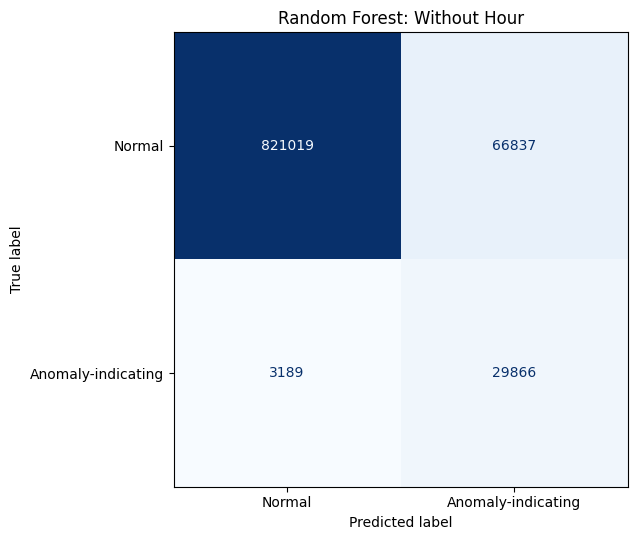

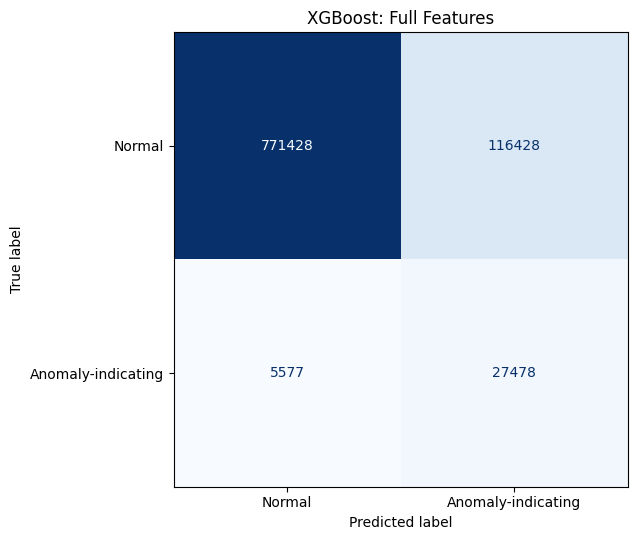

In [ ]:
# Confusion matrices for the best Random Forest and XGBoost scenarios.
for model_name in ["Random Forest", "XGBoost"]:
    model_rows = main_results_df[main_results_df["Model"] == model_name]
    selected_row = (
        model_rows.sort_values(["MCC", "PR-AUC"], ascending=False).iloc[0]
    )
    key = (
        "Random Split",
        model_name,
        selected_row["Scenario"],
        "Random Under Sampling",
    )
    artifact = trained_artifacts[key]
    cm = confusion_matrix(artifact["y_test"], artifact["y_pred"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Anomaly-indicating"],
    )
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    ax.set_title(f"{model_name}: {selected_row['Scenario']}")
    ax.grid(False)
    fig.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    fig.savefig(
        OUTPUT_DIR / f"confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 8. Block-based validation for future-block generalization

In [ ]:
(
    train_block,
    test_block,
    block_encoder,
    block_frequency_maps,
    block_split_metadata,
) = split_and_encode_block_based(df, train_fraction=0.80)

block_split_summary = pd.DataFrame([
    {
        "partition": "train",
        "rows": len(train_block),
        "normal": int((train_block["isError"] == 0).sum()),
        "anomaly": int((train_block["isError"] == 1).sum()),
        "anomaly_prevalence": float(train_block["isError"].mean()),
        "min_block": int(train_block["BlockHeight"].min()),
        "max_block": int(train_block["BlockHeight"].max()),
    },
    {
        "partition": "future-block test",
        "rows": len(test_block),
        "normal": int((test_block["isError"] == 0).sum()),
        "anomaly": int((test_block["isError"] == 1).sum()),
        "anomaly_prevalence": float(test_block["isError"].mean()),
        "min_block": int(test_block["BlockHeight"].min()),
        "max_block": int(test_block["BlockHeight"].max()),
    },
])
display(block_split_summary)
print(block_split_metadata)
block_split_summary.to_csv(OUTPUT_DIR / "block_split_summary.csv", index=False)

Unseen-wallet audit: {'unseen_from_count': 258717, 'unseen_to_count': 298517, 'test_rows': 773597, 'unseen_from_percentage': 33.44338201932014, 'unseen_to_percentage': 38.588179633581824}


,partition,rows,normal,anomaly,anomaly_prevalence,min_block,max_block
0,train,3830958,3670110,160848,0.041986,46230,7131601
1,future-block test,773597,769168,4429,0.005725,7131603,8754331


{'cutoff_block': 7131601, 'train_rows': 3830958, 'test_rows': 773597, 'train_max_block': 7131601, 'test_min_block': 7131603}


In [ ]:
block_results = []

for model_name in ["Random Forest", "XGBoost"]:
    for scenario_name in ["Full Features", "Without Hour"]:
        print("Block validation:", model_name, "|", scenario_name)
        metrics, model, X_test, y_test, y_pred, y_prob = run_experiment(
            model_name=model_name,
            scenario_name=scenario_name,
            feature_names=SCENARIOS[scenario_name],
            train_encoded=train_block,
            test_encoded=test_block,
            training_strategy="Random Under Sampling",
        )
        metrics["Validation Design"] = "Future-block test"
        block_results.append(metrics)

block_results_df = pd.DataFrame(block_results)
display(block_results_df)
block_results_df.to_csv(
    OUTPUT_DIR / "block_based_validation_results.csv", index=False
)

validation_comparison = pd.concat(
    [
        main_results_df[
            (main_results_df["Model"].isin(["Random Forest", "XGBoost"]))
            & (main_results_df["Scenario"].isin(["Full Features", "Without Hour"]))
        ].assign(**{"Validation Design": "Random stratified test"}),
        block_results_df,
    ],
    ignore_index=True,
)
display(validation_comparison)
validation_comparison.to_csv(
    OUTPUT_DIR / "random_vs_block_validation.csv", index=False
)

Block validation: Random Forest | Full Features
Block validation: Random Forest | Without Hour
Block validation: XGBoost | Full Features
Block validation: XGBoost | Without Hour


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds,Validation Design
0,773597,769168,4429,0.005725,762379,6789,4161,268,7057,0.962024,...,3.004936,0.525842,0.991174,0.041015,Random Forest,Full Features,Random Under Sampling,321696,49.124566,Future-block test
1,773597,769168,4429,0.005725,764655,4513,4089,340,4853,0.929940,...,3.091825,0.535450,0.994133,0.067750,Random Forest,Without Hour,Random Under Sampling,321696,54.893533,Future-block test
2,773597,769168,4429,0.005725,768008,1160,4360,69,1229,0.943857,...,2.285163,0.507036,0.998492,0.026656,XGBoost,Full Features,Random Under Sampling,321696,2.647238,Future-block test
3,773597,769168,4429,0.005725,766907,2261,4298,131,2392,0.945234,...,2.464654,0.513319,0.997060,0.036200,XGBoost,Without Hour,Random Under Sampling,321696,6.042194,Future-block test


,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds,Validation Design
0,920911,887856,33055,0.035894,821019,66837,3189,29866,96703,0.691157,...,18.764381,0.914123,0.924721,0.502586,Random Forest,Without Hour,Random Under Sampling,264444,56.536547,Random stratified test
1,920911,887856,33055,0.035894,822167,65689,3657,29398,95087,0.690831,...,18.765981,0.907690,0.926014,0.498478,Random Forest,Full Features,Random Under Sampling,264444,43.512053,Random stratified test
2,920911,887856,33055,0.035894,771428,116428,5577,27478,143906,0.809056,...,14.480773,0.850074,0.868866,0.358697,XGBoost,Full Features,Random Under Sampling,264444,2.290853,Random stratified test
3,920911,887856,33055,0.035894,765950,121906,5489,27566,149472,0.815577,...,14.398112,0.848320,0.862696,0.351453,XGBoost,Without Hour,Random Under Sampling,264444,4.888625,Random stratified test
4,773597,769168,4429,0.005725,762379,6789,4161,268,7057,0.962024,...,3.004936,0.525842,0.991174,0.041015,Random Forest,Full Features,Random Under Sampling,321696,49.124566,Future-block test
5,773597,769168,4429,0.005725,764655,4513,4089,340,4853,0.929940,...,3.091825,0.535450,0.994133,0.067750,Random Forest,Without Hour,Random Under Sampling,321696,54.893533,Future-block test
6,773597,769168,4429,0.005725,768008,1160,4360,69,1229,0.943857,...,2.285163,0.507036,0.998492,0.026656,XGBoost,Full Features,Random Under Sampling,321696,2.647238,Future-block test
7,773597,769168,4429,0.005725,766907,2261,4298,131,2392,0.945234,...,2.464654,0.513319,0.997060,0.036200,XGBoost,Without Hour,Random Under Sampling,321696,6.042194,Future-block test


In [ ]:
block_results_df

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds,Validation Design
0,773597,769168,4429,0.005725,762379,6789,4161,268,7057,0.962024,...,3.004936,0.525842,0.991174,0.041015,Random Forest,Full Features,Random Under Sampling,321696,49.124566,Future-block test
1,773597,769168,4429,0.005725,764655,4513,4089,340,4853,0.929940,...,3.091825,0.535450,0.994133,0.067750,Random Forest,Without Hour,Random Under Sampling,321696,54.893533,Future-block test
2,773597,769168,4429,0.005725,768008,1160,4360,69,1229,0.943857,...,2.285163,0.507036,0.998492,0.026656,XGBoost,Full Features,Random Under Sampling,321696,2.647238,Future-block test
3,773597,769168,4429,0.005725,766907,2261,4298,131,2392,0.945234,...,2.464654,0.513319,0.997060,0.036200,XGBoost,Without Hour,Random Under Sampling,321696,6.042194,Future-block test


In [ ]:
display(block_results_df)

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds,Validation Design
0,773597,769168,4429,0.005725,762379,6789,4161,268,7057,0.962024,...,3.004936,0.525842,0.991174,0.041015,Random Forest,Full Features,Random Under Sampling,321696,49.124566,Future-block test
1,773597,769168,4429,0.005725,764655,4513,4089,340,4853,0.929940,...,3.091825,0.535450,0.994133,0.067750,Random Forest,Without Hour,Random Under Sampling,321696,54.893533,Future-block test
2,773597,769168,4429,0.005725,768008,1160,4360,69,1229,0.943857,...,2.285163,0.507036,0.998492,0.026656,XGBoost,Full Features,Random Under Sampling,321696,2.647238,Future-block test
3,773597,769168,4429,0.005725,766907,2261,4298,131,2392,0.945234,...,2.464654,0.513319,0.997060,0.036200,XGBoost,Without Hour,Random Under Sampling,321696,6.042194,Future-block test


Cek table 10

In [ ]:
display(frequency_results_df)

,Test Rows,Normal Test Count,Anomaly Test Count,Anomaly Prevalence,TN,FP,FN,TP,Alert Count,False Alert Share,...,PR-AUC Baseline,PR-AUC Lift,Balanced Accuracy,Specificity,MCC,Model,Scenario,Training Strategy,Training Rows Used,Training Seconds
0,920911,887856,33055,0.035894,818545,69311,3186,29869,99180,0.698840,...,0.035894,18.645224,0.912775,0.921934,0.495400,Random Forest,Frequency Full Features,Random Under Sampling,264444,32.215483
1,920911,887856,33055,0.035894,818876,68980,3023,30032,99012,0.696683,...,0.035894,17.978637,0.915427,0.922307,0.498955,Random Forest,Frequency Without Hour,Random Under Sampling,264444,35.640774
2,920911,887856,33055,0.035894,778356,109500,4431,28624,138124,0.792766,...,0.035894,16.354066,0.871310,0.876669,0.386901,XGBoost,Frequency Full Features,Random Under Sampling,264444,2.795246
3,920911,887856,33055,0.035894,775615,112241,4323,28732,140973,0.796188,...,0.035894,16.206501,0.871400,0.873582,0.383764,XGBoost,Frequency Without Hour,Random Under Sampling,264444,2.473828


In [ ]:
frequency_results_df.columns.tolist()

['Test Rows',
 'Normal Test Count',
 'Anomaly Test Count',
 'Anomaly Prevalence',
 'TN',
 'FP',
 'FN',
 'TP',
 'Alert Count',
 'False Alert Share',
 'Alerts per 100k',
 'FPR',
 'Accuracy',
 'Precision',
 'Recall',
 'F1-Score',
 'ROC-AUC',
 'PR-AUC',
 'PR-AUC Baseline',
 'PR-AUC Lift',
 'Balanced Accuracy',
 'Specificity',
 'MCC',
 'Model',
 'Scenario',
 'Training Strategy',
 'Training Rows Used',
 'Training Seconds']

In [ ]:
table10 = (
    frequency_results_df[
        [
            "Model",
            "Scenario",
            "Precision",
            "Recall",
            "F1-Score",
            "PR-AUC",
            "MCC"
        ]
    ]
    .copy()
)

display(table10.round(3))


,Model,Scenario,Precision,Recall,F1-Score,PR-AUC,MCC
0,Random Forest,Frequency Full Features,0.301,0.904,0.452,0.669,0.495
1,Random Forest,Frequency Without Hour,0.303,0.909,0.455,0.645,0.499
2,XGBoost,Frequency Full Features,0.207,0.866,0.334,0.587,0.387
3,XGBoost,Frequency Without Hour,0.204,0.869,0.330,0.582,0.384


In [ ]:
table10 = (
    frequency_results_df[
        [
            "Model",
            "Scenario",
            "Precision",
            "Recall",
            "F1-Score",
            "PR-AUC",
            "MCC"
        ]
    ]
    .copy()
    .round(3)
)

display(table10)

,Model,Scenario,Precision,Recall,F1-Score,PR-AUC,MCC
0,Random Forest,Frequency Full Features,0.301,0.904,0.452,0.669,0.495
1,Random Forest,Frequency Without Hour,0.303,0.909,0.455,0.645,0.499
2,XGBoost,Frequency Full Features,0.207,0.866,0.334,0.587,0.387
3,XGBoost,Frequency Without Hour,0.204,0.869,0.330,0.582,0.384


## 9. SHAP and LIME explanations for the selected model

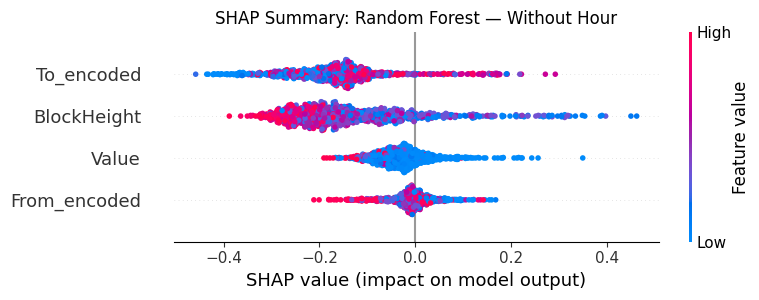

,feature,mean_absolute_shap
0,To_encoded,0.175899
1,BlockHeight,0.165609
2,Value,0.048607
3,From_encoded,0.031294


In [ ]:
# Reuse the model selected by the primary MCC criterion.
selected_model = best_artifact["model"]
selected_features = best_artifact["features"]
X_test_selected = best_artifact["X_test"]
y_test_selected = best_artifact["y_test"]
y_pred_selected = best_artifact["y_pred"]
y_prob_selected = best_artifact["y_prob"]

X_shap = X_test_selected.sample(
    n=min(1000, len(X_test_selected)),
    random_state=SEED,
)

explainer = shap.TreeExplainer(selected_model)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_values_anomaly = raw_shap_values[1]
elif getattr(raw_shap_values, "ndim", 0) == 3:
    shap_values_anomaly = raw_shap_values[:, :, 1]
else:
    shap_values_anomaly = raw_shap_values

shap.summary_plot(
    shap_values_anomaly,
    X_shap,
    show=False,
)
plt.title(
    f"SHAP Summary: {best_main_row['Model']} — {best_main_row['Scenario']}"
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_summary_selected_model.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

global_shap = (
    pd.DataFrame(
        np.abs(shap_values_anomaly),
        columns=X_shap.columns,
    )
    .mean()
    .sort_values(ascending=False)
    .rename("mean_absolute_shap")
    .reset_index()
    .rename(columns={"index": "feature"})
)
display(global_shap)
global_shap.to_csv(OUTPUT_DIR / "global_shap_importance.csv", index=False)

,condition,contribution
0,0.89 < Value <= 4.71,-0.045850
1,4774815.25 < BlockHeight <= 5595792.50,0.036482
2,From_encoded > 491694.00,0.004176
3,To_encoded <= 166063.00,-0.002600


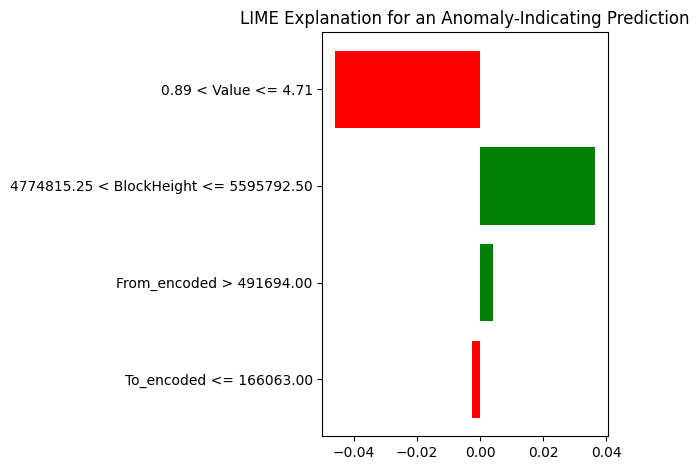

{'row_position': 246, 'true_label': 1, 'predicted_label': 1, 'anomaly_probability': 0.94}


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(
        train_random[selected_features]
        .sample(n=min(50000, len(train_random)), random_state=SEED)
        .astype("float32")
    ),
    feature_names=selected_features,
    class_names=["Normal", "Anomaly-indicating"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)

# Select a true-positive instance with a non-extreme anomaly probability.
candidate_positions = np.where(
    (np.asarray(y_test_selected) == 1)
    & (np.asarray(y_pred_selected) == 1)
    & (np.asarray(y_prob_selected) >= 0.80)
    & (np.asarray(y_prob_selected) <= 0.95)
)[0]
if len(candidate_positions) == 0:
    candidate_positions = np.where(
        (np.asarray(y_test_selected) == 1)
        & (np.asarray(y_pred_selected) == 1)
    )[0]
if len(candidate_positions) == 0:
    raise ValueError("No true-positive instance is available for LIME.")

lime_position = int(candidate_positions[0])
lime_instance = X_test_selected.iloc[lime_position]

def predict_proba_with_names(array):
    frame = pd.DataFrame(array, columns=selected_features)
    return selected_model.predict_proba(frame)

lime_explanation = lime_explainer.explain_instance(
    data_row=lime_instance.to_numpy(),
    predict_fn=predict_proba_with_names,
    num_features=len(selected_features),
)

lime_table = pd.DataFrame(
    lime_explanation.as_list(label=1),
    columns=["condition", "contribution"],
)
display(lime_table)
lime_table.to_csv(OUTPUT_DIR / "lime_local_explanation.csv", index=False)

fig = lime_explanation.as_pyplot_figure(label=1)
plt.title("LIME Explanation for an Anomaly-Indicating Prediction")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "lime_local_explanation.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

lime_metadata = {
    "row_position": lime_position,
    "true_label": int(np.asarray(y_test_selected)[lime_position]),
    "predicted_label": int(np.asarray(y_pred_selected)[lime_position]),
    "anomaly_probability": float(np.asarray(y_prob_selected)[lime_position]),
}
print(lime_metadata)
with open(OUTPUT_DIR / "lime_instance_metadata.json", "w") as f:
    json.dump(lime_metadata, f, indent=2)

In [ ]:
lime_table

,condition,contribution
0,0.89 < Value <= 4.71,-0.045850
1,4774815.25 < BlockHeight <= 5595792.50,0.036482
2,From_encoded > 491694.00,0.004176
3,To_encoded <= 166063.00,-0.002600


In [ ]:
sample_columns = ["TxHash", "BlockHeight", "TimeStamp", "From", "To", "Value", "isError"]
sampled_data = df[sample_columns].sample(n=100, random_state=SEED)
sampled_data.to_csv("ethereum_transaction_selected_sample.csv", index=False)
print("Sampled data saved to 'ethereum_transaction_selected_sample.csv'")

Sampled data saved to 'ethereum_transaction_selected_sample.csv'


In [ ]:
from google.colab import files
files.download("ethereum_transaction_selected_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Export checklist

After all cells finish:

- upload the CSV files in `round3_outputs`;
- upload both confusion-matrix figures;
- upload the SHAP and LIME figures;
- use `random_vs_block_validation.csv` for the temporal/block-validation response;
- use `sampling_strategy_comparison.csv` for the no-resampling baseline response;
- use `operational_alert_burden.csv` for precision/FPR/analyst-workload discussion.

All manuscript metrics must be copied from these exported files, not typed from memory.

In [ ]:
# Package all exported tables and figures for manuscript revision.
import shutil
archive_path = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)
print("Export archive:", archive_path)

Export archive: /content/drive/MyDrive/JURNAL/round3_outputs.zip


In [ ]:
SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "imbalanced_learn": imblearn.__version__,
    "xgboost": xgboost.__version__,
    "shap": shap.__version__,
    "lime": getattr(lime, "__version__", "not exposed"),
}
print(json.dumps(SOFTWARE_VERSIONS, indent=2))

{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pandas": "2.2.2",
  "numpy": "2.0.2",
  "scikit_learn": "1.6.1",
  "imbalanced_learn": "0.14.2",
  "xgboost": "3.3.0",
  "shap": "0.52.0",
  "lime": "not exposed"
}


In [ ]:
!pip show lime

Name: lime
Version: 0.2.0.1
Summary: Local Interpretable Model-Agnostic Explanations for machine learning classifiers
Home-page: http://github.com/marcotcr/lime
Author: Marco Tulio Ribeiro
Author-email: marcotcr@gmail.com
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, scikit-image, scikit-learn, scipy, tqdm
Required-by: 
